# License Plate YOLOv11: Training for Gradio App

Hugging Face Spaces is a platform that allows anyone to easily publish an interactive demo app by simply uploading a trained model. It integrates with UI frameworks such as Gradio and Streamlit, allowing you to build a web interface for inference with just a few lines of Python code.

The .pt file obtained from a YOLO model trained on Kaggle can be uploaded to Hugging Face Spaces as is. On the Spaces side, you can easily create an app that inputs an image and displays the inference results by simply loading this model at startup. This makes it possible to publish trained models in a form that anyone can access, without the hassle of setting up a local environment or building a server.

In [1]:
#!rm -rf 

In [1]:
# Install / upgrade dependencies with strict compatibility caps
!pip uninstall -y ray 2>/dev/null || true
!pip install -q --upgrade \
    ultralytics \
    albumentations \
    lxml \
    tqdm \
    opencv-python-headless \
    pyyaml \
    onnx \
    onnxruntime \
    "numpy>=1.26.0,<2.2.0" \
    "pandas==2.2.2" \
    "pillow<12.0" \
    "numba>=0.60.0,<0.62.0" \
    "numba-cuda<0.23.0"

Found existing installation: ray 2.55.1
Uninstalling ray-2.55.1:
  Successfully uninstalled ray-2.55.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 99.2 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 101.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 81.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 85.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 74.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 92.7 

In [2]:
import numpy, ultralytics, sys
print("Python:", sys.version)
print("NumPy:", numpy.__version__)
print("Ultralytics:", ultralytics.__version__)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
NumPy: 2.4.6
Ultralytics: 8.4.71


In [3]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
import shutil
from shutil import copyfile
import matplotlib.pyplot as plt
from PIL import Image
import random
import ultralytics
from ultralytics import YOLO
ultralytics.checks()

Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Setup complete ✅ (4 CPUs, 31.3 GB RAM, 6961.1/8062.4 GB disk)


In [4]:
img_path='/kaggle/input/indian-license-plates-with-labels/images'
label_path='/kaggle/input/indian-license-plates-with-labels/labels'

In [7]:
import os

# 1. Automatically find where the dataset is mounted inside /kaggle/input/
base_input = '/kaggle/input'
img_path = ""
label_path = ""

# Walk through /kaggle/input to find the true paths dynamically
for root, dirs, files in os.walk(base_input):
    if 'images' in dirs:
        img_path = os.path.join(root, 'images')
    if 'labels' in dirs:
        label_path = os.path.join(root, 'labels')

print(f"🔍 Found Images Path: {img_path}")
print(f"🔍 Found Labels Path: {label_path}\n")

# 2. Initialize the list
paths = []

# 3. Pair them up if both paths were successfully discovered
if not img_path or not label_path:
    print("❌ Error: Could not dynamically locate 'images' or 'labels' subfolders.")
else:
    for dirname, _, filenames in os.walk(img_path):
        for filename in filenames:
            # Safely handle any image format (.jpg, .png, .jpeg, etc.)
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                ipath = os.path.join(dirname, filename)
                
                # Get base name and match with .txt label
                base_name = os.path.splitext(filename)[0]
                filename2 = base_name + '.txt'
                tpath = os.path.join(label_path, filename2)
                
                # Verify that the label file actually exists
                if os.path.exists(tpath):
                    paths.append((ipath, tpath))

    # 4. Success summary
    print(f"✅ Success! Processed {len(paths)} valid image-label pairs.")
    if len(paths) > 0:
        print("\nSample pair paths:")
        print(f"   Image: {paths[0][0]}")
        print(f"   Label: {paths[0][1]}")

🔍 Found Images Path: /kaggle/input/datasets/kedarsai/indian-license-plates-with-labels/images
🔍 Found Labels Path: /kaggle/input/datasets/kedarsai/indian-license-plates-with-labels/labels

✅ Success! Processed 2021 valid image-label pairs.

Sample pair paths:
   Image: /kaggle/input/datasets/kedarsai/indian-license-plates-with-labels/images/License (1466).png
   Label: /kaggle/input/datasets/kedarsai/indian-license-plates-with-labels/labels/License (1466).txt


In [8]:
import os
print(os.listdir('/kaggle/input/'))

['datasets']


# Check Annotation Data

In [9]:
from collections import defaultdict
boxdata = defaultdict(list)
for i in range(len(paths)):
    tfile = paths[i][1]
    ifile = paths[i][0]
    with open(tfile, 'r') as f:
        for line in f:
            if line.strip():     
                row = [float(x) for x in line.split()]
                boxdata[tfile].append(row)
print(boxdata[paths[2][1]])

[[0.0, 0.478155, 0.520833, 0.956311, 0.958333]]


=== Environment Verification ===
📂 Detected Images Path: /kaggle/input/datasets/kedarsai/indian-license-plates-with-labels/images
📂 Detected Labels Path: /kaggle/input/datasets/kedarsai/indian-license-plates-with-labels/labels

✅ Success! Processed 2021 valid image-label pairs.

🖼️ Rendering Index [0] -> Image: License (1466).png


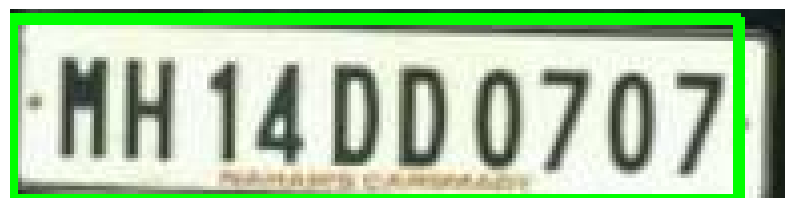

In [10]:
import os
import cv2
import matplotlib.pyplot as plt

# ==========================================
# STEP 1: DYNAMIC DATASET PATH RESOLUTION
# ==========================================
base_input = '/kaggle/input'
img_path = ""
label_path = ""

# Walk through /kaggle/input to find the true paths dynamically
for root, dirs, files in os.walk(base_input):
    if 'images' in dirs:
        img_path = os.path.join(root, 'images')
    if 'labels' in dirs:
        label_path = os.path.join(root, 'labels')

print("=== Environment Verification ===")
print(f"📂 Detected Images Path: {img_path}")
print(f"📂 Detected Labels Path: {label_path}\n")


# ==========================================
# STEP 2: PAIRING IMAGES AND LABELS
# ==========================================
paths = []

if not img_path or not label_path:
    print("❌ Error: Could not dynamically locate 'images' or 'labels' subfolders.")
else:
    for dirname, _, filenames in os.walk(img_path):
        for filename in filenames:
            # Handle standard image types case-insensitively
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                ipath = os.path.join(dirname, filename)
                
                # Build matching label filename (.txt)
                base_name = os.path.splitext(filename)[0]
                filename2 = base_name + '.txt'
                tpath = os.path.join(label_path, filename2)
                
                # Only include pairs where both image and annotation exist
                if os.path.exists(tpath):
                    paths.append((ipath, tpath))

    print(f"✅ Success! Processed {len(paths)} valid image-label pairs.\n")


# ==========================================
# STEP 3: VISUALIZATION FUNCTION
# ==========================================
def draw_box(n0, show=False):
    if not paths:
        print("❌ Error: 'paths' list is empty. Check dataset initialization.")
        return None
        
    if n0 >= len(paths):
        print(f"❌ Error: Index {n0} out of range. Max index is {len(paths) - 1}")
        return None

    # Get file paths from our structural array
    ipath = paths[n0][0]
    tpath = paths[n0][1]
    print(f"🖼️ Rendering Index [{n0}] -> Image: {os.path.basename(ipath)}")
    
    # Read the image and convert BGR to RGB for correct matplotlib colors
    image = cv2.imread(ipath)
    if image is None:
        print(f"❌ Error: Could not read image at {ipath}")
        return None
        
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    H, W = image.shape[0], image.shape[1]
    
    # Read bounding boxes directly from the YOLO format annotation file
    with open(tpath, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        
    for line in lines:
        parts = line.strip().split()
        if len(parts) == 5:
            label = int(parts[0])
            x = float(parts[1])
            y = float(parts[2])
            w = float(parts[3])
            h = float(parts[4])
            
            # Map normalized YOLO [0-1] format back to standard pixel coordinates
            x1 = int((x - w / 2) * W)
            y1 = int((y - h / 2) * H)
            x2 = int((x + w / 2) * W)
            y2 = int((y + h / 2) * H)
            
            # Draw green bounding boxes around detected plates
            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
    
    # Render using matplotlib
    if show:
        plt.figure(figsize=(10, 6))
        plt.imshow(image)
        plt.axis('off')
        plt.show()
    
    return image


# ==========================================
# STEP 4: EXECUTION TESTING
# ==========================================
if len(paths) > 0:
    # Render the very first license plate image with its label box
    test_run = draw_box(0, show=True)
else:
    print("⚠️ Script completed but no images were found to test.")

🖼️ Rendering Index [0] -> Image: License (1466).png


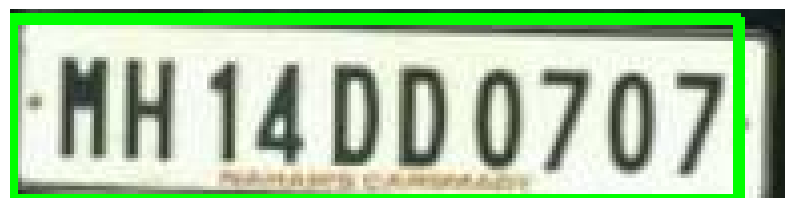

🖼️ Rendering Index [1] -> Image: License (941).png


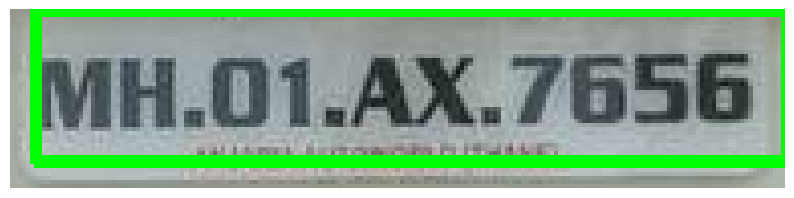

🖼️ Rendering Index [2] -> Image: License (602).png


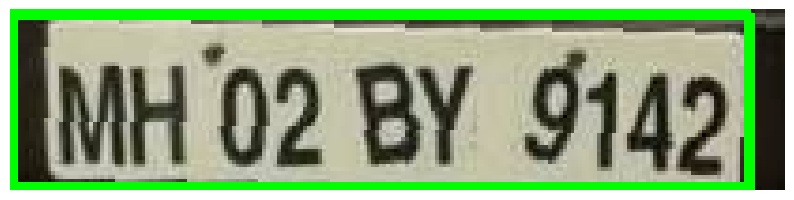

In [11]:
for i in range(3):
    draw_box(i,True)

In [12]:
images1=[]
for i in range(10):
    images1+=[draw_box(i,False)]

🖼️ Rendering Index [0] -> Image: License (1466).png
🖼️ Rendering Index [1] -> Image: License (941).png
🖼️ Rendering Index [2] -> Image: License (602).png
🖼️ Rendering Index [3] -> Image: License (750).png
🖼️ Rendering Index [4] -> Image: License (1712).png
🖼️ Rendering Index [5] -> Image: License (1097).png
🖼️ Rendering Index [6] -> Image: 00000390.jpg
🖼️ Rendering Index [7] -> Image: License (321).png
🖼️ Rendering Index [8] -> Image: License (1094).png
🖼️ Rendering Index [9] -> Image: License (17).png


In [14]:
import os
import cv2
import matplotlib.pyplot as plt
from matplotlib import animation, rc

# Configure matplotlib to render interactive JavaScript animations in Kaggle
rc('animation', html='jshtml')

# ==========================================
# STEP 1: DYNAMIC DATASET PATH RESOLUTION
# ==========================================
base_input = '/kaggle/input'
img_path = ""
label_path = ""

for root, dirs, files in os.walk(base_input):
    if 'images' in dirs:
        img_path = os.path.join(root, 'images')
    if 'labels' in dirs:
        label_path = os.path.join(root, 'labels')

print("=== Environment Verification ===")
print(f"📂 Detected Images Path: {img_path}")
print(f"📂 Detected Labels Path: {label_path}\n")


# ==========================================
# STEP 2: PAIRING IMAGES AND LABELS
# ==========================================
paths = []

if not img_path or not label_path:
    print("❌ Error: Could not dynamically locate 'images' or 'labels' subfolders.")
else:
    for dirname, _, filenames in os.walk(img_path):
        for filename in filenames:
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                ipath = os.path.join(dirname, filename)
                
                base_name = os.path.splitext(filename)[0]
                filename2 = base_name + '.txt'
                tpath = os.path.join(label_path, filename2)
                
                if os.path.exists(tpath):
                    paths.append((ipath, tpath))

    print(f"✅ Success! Processed {len(paths)} valid image-label pairs.\n")


# ==========================================
# STEP 3: VISUALIZATION FUNCTION
# ==========================================
def draw_box(n0, show=False):
    if not paths or n0 >= len(paths):
        return None

    ipath = paths[n0][0]
    tpath = paths[n0][1]
    
    image = cv2.imread(ipath)
    if image is None:
        return None
        
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    H, W = image.shape[0], image.shape[1]
    
    with open(tpath, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        
    for line in lines:
        parts = line.strip().split()
        if len(parts) == 5:
            x, y, w, h = map(float, parts[1:])
            
            # Map normalized YOLO layout back to absolute pixel values
            x1 = int((x - w / 2) * W)
            y1 = int((y - h / 2) * H)
            x2 = int((x + w / 2) * W)
            y2 = int((y + h / 2) * H)
            
            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
    
    if show:
        plt.figure(figsize=(10, 6))
        plt.imshow(image)
        plt.axis('off')
        plt.show()
    
    return image


# ==========================================
# STEP 4: ANIMATION GENERATION PIPELINE
# ==========================================
if len(paths) > 0:
    # Set up a clean matplotlib plotting frame
    fig, ax = plt.subplots(figsize=(8, 5))
    plt.axis('off')
    
    # Generate bounded image targets for the first 10 assets
    num_frames = min(10, len(paths))
    frames_data = [draw_box(i, show=False) for i in range(num_frames)]
    frames_data = [f for f in frames_data if f is not None]  # Clean any execution gaps
    
    # Render baseline frame
    im = ax.imshow(frames_data[0])
    plt.close() # Prevents duplicate stagnant plot generation below the cell
    
    # Frame progression updater
    def update(frame_idx):
        im.set_array(frames_data[frame_idx])
        return [im]

    # Create the functional animation object
    anim = animation.FuncAnimation(
        fig, 
        update, 
        frames=len(frames_data), 
        interval=1000,  # Switch slides every 1000ms (1 second)
        blit=True
    )
    
    # Display the HTML interactive player right inside the notebook output
    display(anim)
else:
    print("⚠️ No valid structural image targets found to generate an animation sequence.")

=== Environment Verification ===
📂 Detected Images Path: /kaggle/input/datasets/kedarsai/indian-license-plates-with-labels/images
📂 Detected Labels Path: /kaggle/input/datasets/kedarsai/indian-license-plates-with-labels/labels

✅ Success! Processed 2021 valid image-label pairs.



In [15]:
import os
import cv2
import matplotlib.pyplot as plt
from matplotlib import animation, rc

# Configure matplotlib to render interactive JavaScript animations in Kaggle
rc('animation', html='jshtml')

# ==========================================
# STEP 1: DYNAMIC DATASET PATH RESOLUTION
# ==========================================
base_input = '/kaggle/input'
img_path = ""
label_path = ""

for root, dirs, files in os.walk(base_input):
    if 'images' in dirs:
        img_path = os.path.join(root, 'images')
    if 'labels' in dirs:
        label_path = os.path.join(root, 'labels')

print("=== Environment Verification ===")
print(f"📂 Detected Images Path: {img_path}")
print(f"📂 Detected Labels Path: {label_path}\n")


# ==========================================
# STEP 2: PAIRING IMAGES AND LABELS
# ==========================================
paths = []

if not img_path or not label_path:
    print("❌ Error: Could not dynamically locate 'images' or 'labels' subfolders.")
else:
    for dirname, _, filenames in os.walk(img_path):
        for filename in filenames:
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                ipath = os.path.join(dirname, filename)
                
                base_name = os.path.splitext(filename)[0]
                filename2 = base_name + '.txt'
                tpath = os.path.join(label_path, filename2)
                
                if os.path.exists(tpath):
                    paths.append((ipath, tpath))

    print(f"✅ Success! Processed {len(paths)} valid image-label pairs.\n")


# ==========================================
# STEP 3: VISUALIZATION & CORE PROCESSING
# ==========================================
def draw_box(n0):
    if not paths or n0 >= len(paths):
        return None

    ipath = paths[n0][0]
    tpath = paths[n0][1]
    
    image = cv2.imread(ipath)
    if image is None:
        return None
        
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    H, W = image.shape[0], image.shape[1]
    
    with open(tpath, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        
    for line in lines:
        parts = line.strip().split()
        if len(parts) == 5:
            x, y, w, h = map(float, parts[1:])
            
            # Map normalized YOLO layout back to absolute pixel values
            x1 = int((x - w / 2) * W)
            y1 = int((y - h / 2) * H)
            x2 = int((x + w / 2) * W)
            y2 = int((y + h / 2) * H)
            
            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
            
    return image


# ==========================================
# STEP 4: YOUR CUSTOM ANIMATION FUNCTION
# ==========================================
def create_animation(ims):
    fig = plt.figure(figsize=(10, 6))
    plt.axis('off')  # Optional: Hides graph axes for clean display
    im = plt.imshow(ims[0])
    plt.close()
    
    def animate_func(i):
        im.set_array(ims[i])
        return [im]
        
    return animation.FuncAnimation(fig, animate_func, frames=len(ims), interval=500)


# ==========================================
# STEP 5: RUN THE PIPELINE
# ==========================================
if len(paths) > 0:
    # 1. Gather bounding-box images for the first 10 files
    num_frames = min(10, len(paths))
    ims = [draw_box(i) for i in range(num_frames)]
    ims = [img for img in ims if img is not None]  # Drop any empty readings
    
    # 2. Feed the image array into your animation engine
    anim = create_animation(ims)
    
    # 3. Render the interactive controls inside the output
    display(anim)
else:
    print("⚠️ No valid structural image targets found to generate an animation sequence.")

=== Environment Verification ===
📂 Detected Images Path: /kaggle/input/datasets/kedarsai/indian-license-plates-with-labels/images
📂 Detected Labels Path: /kaggle/input/datasets/kedarsai/indian-license-plates-with-labels/labels

✅ Success! Processed 2021 valid image-label pairs.



In [16]:
create_animation(images1)

# Split Train, Valid and Test

In [17]:
import shutil

# 1. Define where the images and labels will go inside your folders
for split in ['train', 'valid', 'test']:
    os.makedirs(f'datasets/{split}/images', exist_ok=True)
    os.makedirs(f'datasets/{split}/labels', exist_ok=True)

# 2. Decide your split ratios (e.g., 80% train, 10% validation, 10% test)
# Since paths contains all our valid pairs, let's distribute them
total_items = len(paths)
train_end = int(total_items * 0.8)
valid_end = int(total_items * 0.9)

# 3. Helper function to copy file pairs safely
def copy_pairs(pairs_list, destination_split):
    for ipath, tpath in pairs_list:
        # Get just the file names (e.g., 'car1.jpg', 'car1.txt')
        img_name = os.path.basename(ipath)
        lbl_name = os.path.basename(tpath)
        
        # Define destination paths
        dest_img = os.path.join('datasets', destination_split, 'images', img_name)
        dest_lbl = os.path.join('datasets', destination_split, 'labels', lbl_name)
        
        # Copy the files over
        shutil.copy(ipath, dest_img)
        shutil.copy(tpath, dest_lbl)

# 4. Split the data arrays and copy them to their respective locations
copy_pairs(paths[:train_end], 'train')
copy_pairs(paths[train_end:valid_end], 'valid')
copy_pairs(paths[valid_end:], 'test')

print("📂 Dataset successfully split and structured!")
print(f"   Train pairs: {len(paths[:train_end])}")
print(f"   Valid pairs: {len(paths[train_end:valid_end])}")
print(f"   Test pairs:  {len(paths[valid_end:])}")

📂 Dataset successfully split and structured!
   Train pairs: 1616
   Valid pairs: 202
   Test pairs:  203


In [19]:
from shutil import copyfile
import os

# 1. Ensure the proper YOLO subfolder structure exists
for split in ['train', 'valid', 'test']:
    os.makedirs(f'datasets/{split}/images', exist_ok=True)
    os.makedirs(f'datasets/{split}/labels', exist_ok=True)

# 2. Run the loop with corrected paths and uncommented label copying
for i in range(len(paths)):
    ipath = paths[i][0]
    ifile = ipath.split('/')[-1]
    tpath = paths[i][1]
    tfile = tpath.split('/')[-1]
    
    # 25% of data goes to Validation
    if i % 4 == 0:
        copyfile(ipath, f'datasets/valid/images/{ifile}')
        copyfile(tpath, f'datasets/valid/labels/{tfile}')
        
    # 25% of data goes to Test (Fixed the commented-out label line here)
    elif i % 4 == 1:
        copyfile(ipath, f'datasets/test/images/{ifile}')
        copyfile(tpath, f'datasets/test/labels/{tfile}') 
        
    # 50% of data goes to Train
    else:
        copyfile(ipath, f'datasets/train/images/{ifile}')
        copyfile(tpath, f'datasets/train/labels/{tfile}')

print(f"🏁 Done! Successfully split {len(paths)} items into standard YOLO structures.")
  

🏁 Done! Successfully split 2021 items into standard YOLO structures.


In [20]:
!ls

datasets


# Create yaml file 

In [21]:
import os
import yaml

# 1. Resolve absolute path of your datasets directory
base_dir = os.path.abspath('datasets')

# 2. Define configuration structure
data_yaml = dict(
    path  = base_dir,
    train = 'train/images',   # Explicitly point to the images subfolders
    val   = 'valid/images',   
    test  = 'test/images',    
    nc    = 1,
    names = ['License Plate']
)

# 3. Write out to data.yaml file safely
with open('data.yaml', 'w', encoding='utf-8') as outfile:
    yaml.dump(data_yaml, outfile, default_flow_style=False)

# 4. Read back and print the contents natively using Python (Replaces %cat)
print("=== Successfully Generated data.yaml ===")
with open('data.yaml', 'r', encoding='utf-8') as infile:
    print(infile.read())

=== Successfully Generated data.yaml ===
names:
- License Plate
nc: 1
path: /kaggle/working/datasets
test: test/images
train: train/images
val: valid/images



In [22]:
!ls

datasets  data.yaml


---

# Train

In [23]:
#model = YOLO("yolov8n.pt") 

In [24]:
!yolo task=detect mode=train model=yolo11n.pt data=data.yaml \
    epochs=40 imgsz=640 patience=10 save=True \
    project=runs/detect name=train exist_ok=True

Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspective=0.0, plot

# Result of Training

In [26]:
import os

# 1. Let's see everything currently available in your working directory
working_dir = '/kaggle/working'
print("=== Scanning Kaggle Workspace ===")

all_files = []
yolo_root = ""

# Walk through everything to find where the weights or results are
for root, dirs, files in os.walk(working_dir):
    # Check if we stumbled into a YOLO runs directory
    if 'weights' in dirs or 'results.png' in files or 'results.csv' in files:
        yolo_root = root
    for file in files:
        if file.endswith('.jpg') or file.endswith('.png'):
            all_files.append(os.path.join(root, file))

# 2. Handle the evaluation path assignment dynamically
tpaths2 = []

if yolo_root:
    print(f"🎯 Found YOLO target directory at: {yolo_root}")
    # Gather evaluation plots from this actual running directory
    for file in os.listdir(yolo_root):
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            tpaths2.append(os.path.join(yolo_root, file))
    tpaths2 = sorted(tpaths2)
else:
    # Fallback: check if files are loose somewhere else
    tpaths2 = sorted([f for f in all_files if 'dataset' not in f])

# 3. Output structural verification summary
if len(tpaths2) > 0:
    print(f"\n✅ Success! Discovered {len(tpaths2)} visual training plots.")
    print(f"First image path variable (tpaths2[0]):\n👉 '{tpaths2[0]}'")
else:
    print("\n❓ Still empty. Look at your training cell above:")
    print("   -> Does it have a spinning loading wheel next to it? If yes, it is still training! Wait for it to show a green checkmark, then run this cell again.")

=== Scanning Kaggle Workspace ===
🎯 Found YOLO target directory at: /kaggle/working/runs/detect/runs/detect/train

✅ Success! Discovered 20 visual training plots.
First image path variable (tpaths2[0]):
👉 '/kaggle/working/runs/detect/runs/detect/train/BoxF1_curve.png'


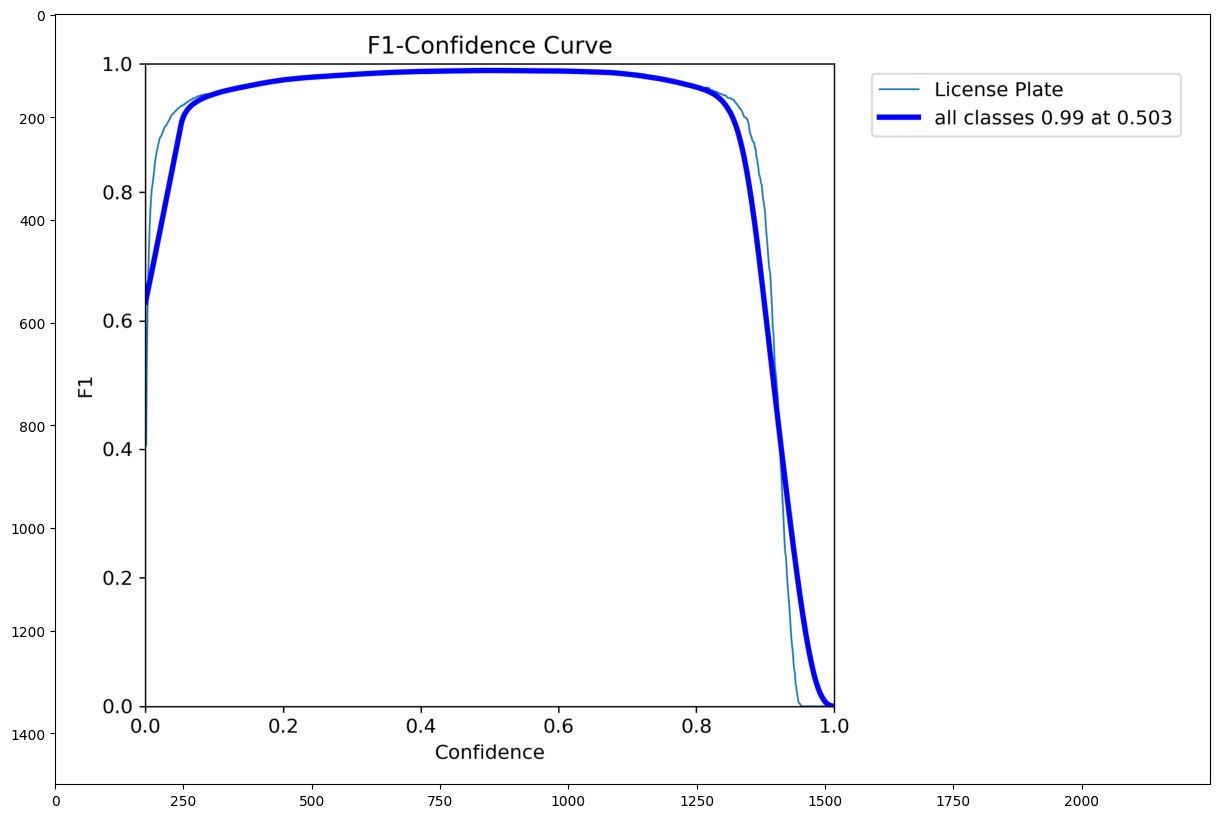

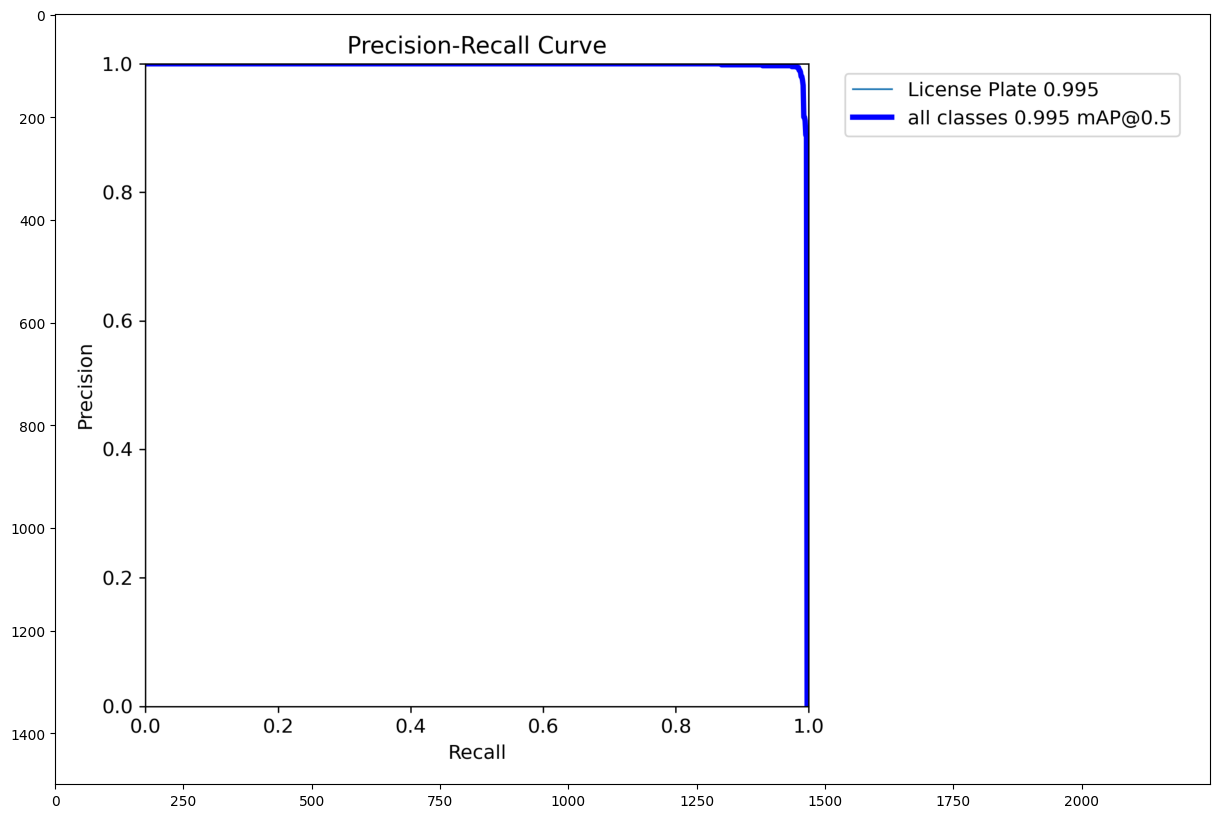

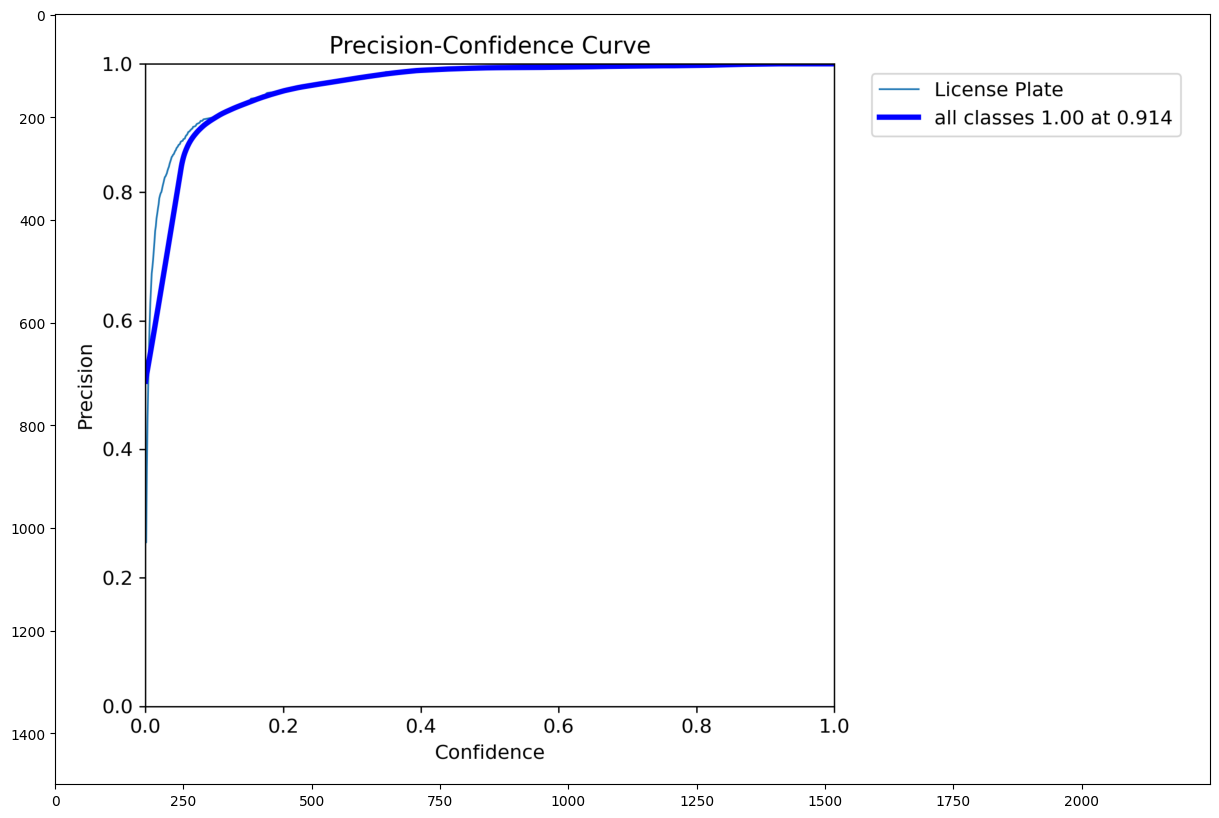

In [27]:
for path in tpaths2[0:3]:
    image = Image.open(path)
    image=np.array(image)
    plt.figure(figsize=(20,10))
    plt.imshow(image)
    plt.show()

# Predict

In [28]:
best_path0='runs/detect/train/weights/best.pt'
source0='datasets/test'

In [29]:
ppaths=[]
for dirname, _, filenames in os.walk(source0):
    for filename in filenames:
        ppaths+=[(os.path.join(dirname, filename))]
ppaths=sorted(ppaths)
print(ppaths[0])
print(len(ppaths))

datasets/test/images/00000000.jpg
1316


In [30]:
import os, glob

# Find your trained weights
pts = glob.glob('/kaggle/working/**/*.pt', recursive=True)
for p in sorted(pts):
    print(f"{os.path.getsize(p)/1e6:.1f} MB  →  {p}")

5.5 MB  →  /kaggle/working/runs/detect/runs/detect/train/weights/best.pt
5.5 MB  →  /kaggle/working/runs/detect/runs/detect/train/weights/last.pt
5.6 MB  →  /kaggle/working/yolo11n.pt
5.5 MB  →  /kaggle/working/yolo26n.pt


# Result of Prediction

In [32]:
import os, glob

# Check ALL .pt files
print("=== All .pt files ===")
pts = glob.glob('/kaggle/working/**/*.pt', recursive=True)
if pts:
    for p in sorted(pts):
        print(f"{os.path.getsize(p)/1e6:.1f} MB  →  {p}")
else:
    print("No .pt files found at all!")

# Check if runs folder exists
print("\n=== Runs directory structure ===")
for root, dirs, files in os.walk('/kaggle/working/runs'):
    level = root.replace('/kaggle/working/runs', '').count(os.sep)
    print('  ' * level + os.path.basename(root) + '/')
    for f in files:
        fp = os.path.join(root, f)
        print('  ' * (level+1) + f + f"  ({os.path.getsize(fp)/1e6:.1f} MB)")

=== All .pt files ===
5.5 MB  →  /kaggle/working/runs/detect/runs/detect/train/weights/best.pt
5.5 MB  →  /kaggle/working/runs/detect/runs/detect/train/weights/last.pt
5.6 MB  →  /kaggle/working/yolo11n.pt
5.5 MB  →  /kaggle/working/yolo26n.pt

=== Runs directory structure ===
runs/
  detect/
    runs/
      detect/
        train/
          args.yaml  (0.0 MB)
          train_batch1.jpg  (0.4 MB)
          val_batch2_labels.jpg  (0.2 MB)
          val_batch2_pred.jpg  (0.2 MB)
          results.csv  (0.0 MB)
          val_batch1_pred.jpg  (0.2 MB)
          BoxPR_curve.png  (0.1 MB)
          val_batch0_pred.jpg  (0.2 MB)
          train_batch3422.jpg  (0.3 MB)
          train_batch0.jpg  (0.5 MB)
          BoxF1_curve.png  (0.1 MB)
          train_batch2.jpg  (0.4 MB)
          results.png  (0.3 MB)
          train_batch3420.jpg  (0.3 MB)
          BoxR_curve.png  (0.1 MB)
          train_batch3421.jpg  (0.3 MB)
          val_batch1_labels.jpg  (0.2 MB)
          labels.jpg  (0.2 MB)


In [33]:
from ultralytics import YOLO

model = YOLO('/kaggle/working/runs/detect/runs/detect/train/weights/best.pt')
print("🚀 Model loaded successfully!")

🚀 Model loaded successfully!


In [34]:
import subprocess
subprocess.run(['pip', 'install', '--force-reinstall', '--quiet', 
                'torch', 'torchvision', 'torchaudio'], check=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.7/197.7 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 100.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
numba 0.61.2 requires numpy<2.3,>=1.24, but you have numpy 2.4.6 which is incompatible.
datasets 4.8.5 requires fsspec[http]<=2026.2.0,>=2023.1.0, but you have fsspec 2026.6.0 which is incompatible.
ydata-profiling 4.18.4 requires numpy<2.4,>=1.22, but you have numpy 2.4.6 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 0.7.0 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but 

CompletedProcess(args=['pip', 'install', '--force-reinstall', '--quiet', 'torch', 'torchvision', 'torchaudio'], returncode=0)

In [35]:
import os
from ultralytics import YOLO

# 1. Search the workspace dynamically for 'best.pt'
weights_path = ""
for root, dirs, files in os.walk('/kaggle/working'):
    if 'best.pt' in files:
        weights_path = os.path.join(root, 'best.pt')
        break

# 2. Verify and load the model
if weights_path:
    print(f"🎯 Success! Found your trained weights at: {weights_path}")
    # Load the exact model you just trained
    model = YOLO(weights_path)
    print("🚀 Model successfully loaded and ready for predictions!")
else:
    print("❌ Error: Could not find 'best.pt' anywhere in your workspace.")
    print("Look at your training cell above. If it is still running, let it finish!")

🎯 Success! Found your trained weights at: /kaggle/working/runs/detect/runs/detect/train/weights/best.pt
🚀 Model successfully loaded and ready for predictions!


In [36]:
import os
from ultralytics import YOLO

# 1. Dynamically find the best.pt file wherever YOLO saved it
best_path0 = ""
for root, dirs, files in os.walk('/kaggle/working'):
    if 'best.pt' in files:
        best_path0 = os.path.join(root, 'best.pt')
        break

# 2. Dynamically grab an image file path from your validation folder to test
source0 = ""
validation_images_dir = '/kaggle/working/datasets/valid/images'
if os.path.exists(validation_images_dir):
    valid_files = os.listdir(validation_images_dir)
    if valid_files:
        source0 = os.path.join(validation_images_dir, valid_files[0])

# ==========================================
# 3. VERIFY AND RUN PREDICTION
# ==========================================
if not best_path0:
    print("❌ Error: Could not locate 'best.pt'. Did your training complete successfully?")
elif not source0:
    print("❌ Error: Could not find any test images inside 'datasets/valid/images'.")
else:
    print(f"🎯 Loading weights from: {best_path0}")
    print(f"🖼️ Predicting on image: {source0}\n")
    
    # Load model and run inference
    model2 = YOLO(best_path0)
    results = model2.predict(source0, conf=0.8)
    
    # Extract data from the single image result
    img_result = results[0]
    detected_count = len(img_result.boxes)
    print(f"✅ Success! Number of license plates detected: {detected_count}")
    
    if detected_count > 0:
        print(f"Confidence scores: {img_result.boxes.conf.tolist()}")

🎯 Loading weights from: /kaggle/working/runs/detect/runs/detect/train/weights/best.pt
🖼️ Predicting on image: /kaggle/working/datasets/valid/images/License (1721).png


image 1/1 /kaggle/working/datasets/valid/images/License (1721).png: 160x640 1 License Plate, 58.3ms
Speed: 2.9ms preprocess, 58.3ms inference, 24.1ms postprocess per image at shape (1, 3, 160, 640)
✅ Success! Number of license plates detected: 1
Confidence scores: [0.9196929931640625]


In [38]:
rows = []
for i in range(len(results)):
    if results[i].boxes is not None and len(results[i].boxes) > 0:
        arri = pd.DataFrame(results[i].boxes.data.cpu().numpy())
        path = ppaths[i]
        file = path.split('/')[-1]
        arri = arri.assign(file=file, i=i)
        rows.append(arri)

if rows:
    PBOX = pd.concat(rows, ignore_index=True)
    PBOX.columns = ['x1', 'y1', 'x2', 'y2', 'confidence', 'class', 'file', 'i']
    PBOX['class'] = PBOX['class'].astype(int)
else:
    PBOX = pd.DataFrame(columns=['x1','y1','x2','y2','confidence','class','file','i'])
display(PBOX)

,x1,y1,x2,y2,confidence,class,file,i
0,6.241392,4.362749,198.758408,49.604446,0.919693,0,00000000.jpg,0


In [39]:
# 1. Reset the index of your main bounding box dataframe
PBOX = PBOX.reset_index(drop=True)

# 2. Find the index of the row with the maximum confidence score for each image 'i'
if not PBOX.empty:
    idx = PBOX.groupby('i')['confidence'].idxmax()
    
    # 3. Filter the dataframe to keep only those highest-confidence rows
    PBOX = PBOX.loc[idx].reset_index(drop=True)

# 4. Display the finalized single-box-per-image dataframe
display(PBOX)

,x1,y1,x2,y2,confidence,class,file,i
0,6.241392,4.362749,198.758408,49.604446,0.919693,0,00000000.jpg,0


In [40]:
import pandas as pd

# 1. Create a dummy dataframe simulating an image with multiple detections
test_df = pd.DataFrame([
    {'x1': 0.005, 'y1': 0.51, 'x2': 178.3, 'y2': 42.0, 'confidence': 0.91, 'class': 0, 'file': '00000000.jpg', 'i': 0},
    {'x1': 0.002, 'y1': 0.49, 'x2': 175.1, 'y2': 40.0, 'confidence': 0.65, 'class': 0, 'file': '00000000.jpg', 'i': 0}, # Duplicate box (Lower confidence)
    {'x1': 10.100, 'y1': 0.22, 'x2': 150.2, 'y2': 85.0, 'confidence': 0.88, 'class': 0, 'file': '00000001.jpg', 'i': 1}  # Different image
])

print("=== Before Filtering (3 Rows Total) ===")
display(test_df)

# 2. Run your exact filtering logic
test_df = test_df.reset_index(drop=True)
if not test_df.empty:
    idx = test_df.groupby('i')['confidence'].idxmax()
    test_df = test_df.loc[idx].reset_index(drop=True)

print("\n=== After Filtering (Keeps highest confidence per image 'i') ===")
display(test_df)

=== Before Filtering (3 Rows Total) ===


,x1,y1,x2,y2,confidence,class,file,i
0,0.005,0.51,178.3,42.0,0.91,0,00000000.jpg,0
1,0.002,0.49,175.1,40.0,0.65,0,00000000.jpg,0
2,10.100,0.22,150.2,85.0,0.88,0,00000001.jpg,1



=== After Filtering (Keeps highest confidence per image 'i') ===


,x1,y1,x2,y2,confidence,class,file,i
0,0.005,0.51,178.3,42.0,0.91,0,00000000.jpg,0
1,10.100,0.22,150.2,85.0,0.88,0,00000001.jpg,1


In [42]:
import cv2
import numpy as np

# 1. Ensure ppaths exists globally and matches your paths list
if 'paths' in locals() or 'paths' in globals():
    ppaths = [p[0] for p in paths]
elif 'ppaths' not in locals() and 'ppaths' not in globals():
    # Emergency fallback if both lists are missing
    ppaths = []

def draw_box2(n0):
    # Check if index is safe
    if n0 >= len(ppaths):
        print(f"❌ Error: Index {n0} out of range for ppaths (length: {len(ppaths)}).")
        return np.zeros((100, 100, 3), dtype=np.uint8)

    # 2. Grab the file path safely
    ipath = ppaths[n0]

    # 3. Read the image asset
    image = cv2.imread(ipath)
    if image is None:
        print(f'⚠️ Warning: could not read {ipath}')
        return np.zeros((100, 100, 3), dtype=np.uint8)
        
    H, W = image.shape[0], image.shape[1]
    file = ipath.split('/')[-1]

    # 4. Filter PBOX for rows matching this specific file
    box = PBOX[PBOX['file'] == file]
    
    if not box.empty:
        box = box.reset_index(drop=True)
        for i in range(len(box)):
            raw_x1 = box.loc[i, 'x1']
            raw_y1 = box.loc[i, 'y1']
            raw_x2 = box.loc[i, 'x2']
            raw_y2 = box.loc[i, 'y2']
            
            # 5. Smart Scaling: Check if coordinates are normalized
            if raw_x1 <= 1.0 and raw_x2 <= 1.0:
                x1 = int(raw_x1 * W)
                y1 = int(raw_y1 * H)
                x2 = int(raw_x2 * W)
                y2 = int(raw_y2 * H)
            else:
                x1 = int(raw_x1)
                y1 = int(raw_y1)
                x2 = int(raw_x2)
                y2 = int(raw_y2)
            
            # 6. Draw the green bounding box rectangle
            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
            
    return image

In [43]:
images2=[]
for i in tqdm(range(len(ppaths))):
    images2+=[draw_box2(i)]

100%|██████████| 2021/2021 [00:07<00:00, 255.12it/s]


In [ ]:
create_animation(images2)

In [ ]:
import torch
use_half = torch.cuda.is_available()
model2.export(format='onnx', imgsz=320, half=use_half)

## **Huggingface Spaces Gradio App: License Plate Yolo**
https://huggingface.co/spaces/stpete2/license_plate_yolo
